# Group 4 | Nancy Melchert, Sophia Menchaca, Blythe Weng

## Galaxy Classification

# INFORMATION ABOUT THE DATASET

From the [zenodo.org](https://zenodo.org/records/11117528) site:

## Overview

GalaxiesML is a machine learning-ready dataset of galaxy images, photometry, redshifts, and structural parameters. It is designed for machine learning applications in astrophysics, particularly for tasks such as redshift estimation and galaxy morphology classification. The dataset comprises **286,401 galaxy images** from the Hyper-Suprime-Cam (HSC) Survey PDR2 in five filters: g, r, i, z, y, with spectroscopically confirmed redshifts as ground truth.

This dataset is particularly useful for developing machine learning models for upcoming large-scale surveys like **LSST** and **Euclid**.

## Features

- **286,401 galaxy images** in five photometric bands (g, r, i, z, y).
- Spectroscopic redshifts for each galaxy, with redshift values ranging from **0.01 to 4**.
- Morphological parameters derived from galaxy images, including **Sérsic index**, **half-light radius**, and **ellipticity**.
- **Machine learning-friendly formats**: images are provided in **HDF5** format, along with CSV metadata.


## Examples of Using GalaxiesML

Examples of uses of GalaxiesML are outlined in Do et al. (2024). The repository for example code are here:

https://github.com/astrodatalab/galaxiesml_examples


## Citation

Please cite the following papers if you use this dataset in your work:

1. **GalaxiesML Dataset**:
- Do, T. et al., *GalaxiesML: A Dataset of Galaxy Images, Photometry, Redshifts, and Structural Parameters for Machine Learning*. arXiv:2410.00271 (2024), https://arxiv.org/abs/2410.00271 

2. **Hyper Suprime-Cam Subaru Strategic Program (HSC PDR2)**:
- Aihara, H., et al., *Second Data Release of the Hyper Suprime-Cam Subaru Strategic Program*. Publications of the Astronomical Society of Japan, 71(6), 114 (2019). DOI: [10.1093/pasj/psz103](https://doi.org/10.1093/pasj/psz103)

3. **Spectroscopic Surveys**:
- Several publicly available spectroscopic redshift catalogs were used in creating this dataset. Notable sources include:
- **zCOSMOS Survey**: Lilly, S. J., et al., *The zCOSMOS 10k-Bright Spectroscopic Sample*. The Astrophysical Journal Supplement Series, 184(2), 218-229 (2009). DOI: [10.1088/0067-0049/184/2/218](https://doi.org/10.1088/0067-0049/184/2/218)
- **VIMOS Public Extragalactic Survey (VIPERS)**: Garilli, B., et al., *The VIMOS Public Extragalactic Survey (VIPERS): First Data Release of 57,204 Spectroscopic Measurements*. Astronomy & Astrophysics, 562, A23 (2014). DOI: [10.1051/0004-6361/201322790](https://doi.org/10.1051/0004-6361/201322790)
- **DEEP2 Survey**: Newman, J. A., et al., *The DEEP2 Galaxy Redshift Survey: Design, Observations, Data Reduction, and Redshifts*. The Astrophysical Journal Supplement Series, 208(1), 5 (2013). DOI: [10.1088/0067-0049/208/1/5](https://doi.org/10.1088/0067-0049/208/1/5)


## How to Access

The dataset is publicly available on **Zenodo** with the DOI: **[10.5281/zenodo.11117528](https://doi.org/10.5281/zenodo.11117528)**.

## License

This dataset is licensed under a **Creative Commons Attribution 4.0 International License (CC BY 4.0)**. You are free to share and adapt the dataset as long as appropriate credit is given. For more details, visit: **[CC BY 4.0 License](https://creativecommons.org/licenses/by/4.0/)**.

Please cite the references mentioned above if you use this dataset in your work.

THIS IS TO SEE IF I CAN FIGURE OUT THE PUSH/PULL AND GET IT INTO THE MAIN BRANCH

# DOWNLOAD AND EXPLORE THE DATASET

Datasets are `.hdf5`. The h5py package is a Pythonic interface to the HDF5 binary data format. 
[H5PY Documentation](https://docs.h5py.org/en/stable/)

In [1]:
%pip install astropy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# install appropriate libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tkinter import Tk, filedialog

try:
    import torch
except ImportError:
    %pip install torch

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

try:
    import h5py
except ImportError: 
    %pip install h5py

In [4]:
# Install Hugging Face datasets
%matplotlib inline
try:
    from datasets import load_dataset
except ImportError:
    %pip install datasets

## MLGalaxies Data

In [5]:
# CoPilot helped with this code snippet to create a custom PyTorch Dataset class for loading
class GalaxyDataset(Dataset):
    def __init__(self, hdf5_path, image_key="image", label_key=None):
        self.hdf5_path = hdf5_path
        self.image_key = image_key
        self.label_key = label_key

        # Open the file to get the length of the dataset, then close it
        with h5py.File(self.hdf5_path, "r") as f:
            self.length = f[self.image_key].shape[0]
    
        self.file = None  # Will hold the open HDF5 file

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        if self.file is None:
            # Open the file inside the active process
            self.file = h5py.File(self.hdf5_path, "r")

        #Extract data (HDF5 slicing loads only this slice into RAM)    
        image = self.file[self.image_key][idx]
        img_tensor = torch.tensor(image, dtype=torch.float32)

        if self.label_key is None:
            return img_tensor
        
        label = self.file[self.label_key][idx]
        label_tensor = torch.tensor(label, dtype=torch.long) if label is not None else None

        return img_tensor, label_tensor


In [7]:
# Prompt user for the HDF5 file path for portability
# TODO: Update this to use a config file or environment variable for better reproducibility

Tk().withdraw()  # Hide the main window
Tk().attributes("-topmost", True)  # Bring the file dialog to the front

hdf5_path = filedialog.askopenfilename(
    title="Select HDF5 file for training", 
    filetypes=[("HDF5 files", "*.hdf5"), ("All files", "*.*")])

Tk().destroy()  # Close the file dialog

# Load the HDF5 file and read the images
if not hdf5_path:
    raise ValueError("No file selected. Please select an HDF5 file.")

with h5py.File(hdf5_path, "r") as f:
    print("Keys in the HDF5 file:", list(f.keys()))
# Use lazy-loading dataset
dataset = GalaxyDataset(hdf5_path, image_key="image", label_key=None)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total Images: {len(dataset)}")

Keys in the HDF5 file: ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sersic_index', 'ra', 'skymap_id', 'specz_dec', 'sp

In [8]:
def print_image(idx=0, dataset=None, band_names=("g", "r", "i", "z", "y")):
    if dataset is None:
        raise ValueError("Pass your GalaxyDataset instance, e.g., print_image(0, dataset)")

    sample = dataset[idx]
    # GalaxyDataset returns (image_tensor); support image-only datasets too
    img_tensor = sample
    label_text = None

    flux = img_tensor.detach().cpu().numpy()  # expected shape: (C, H, W)

    plt.figure(figsize=(12, 3))
    for i in range(flux.shape[0]):
        plt.subplot(1, flux.shape[0], i + 1)
        title = band_names[i] if i < len(band_names) else f"band {i}"
        if i == 0 and label_text is not None:
            title = f"{title} | {label_text}"
        plt.title(title)
        plt.imshow(flux[i], cmap="gray_r", origin="lower")
        plt.axis("off")
    plt.tight_layout()  
    plt.show()

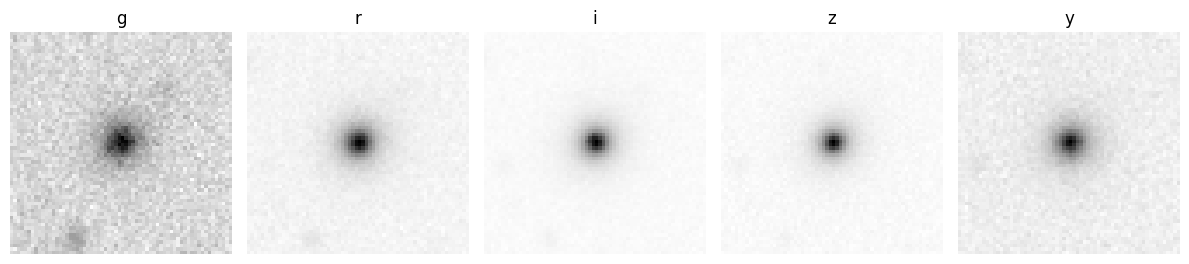

In [9]:
print_image(200, dataset)

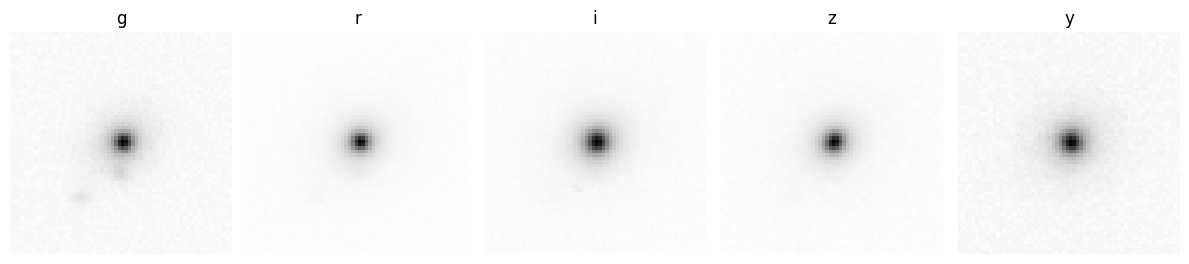

In [10]:
print_image(idx=0, dataset=dataset)

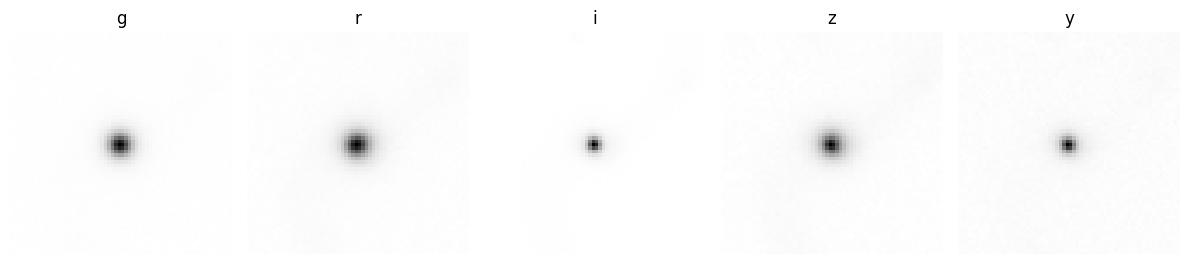

In [12]:
print_image(idx=9999, dataset=dataset)

In [13]:
# csv files are inside a data folder, but then in .gitignore because of the size, so we need to specify the path to read them

images_df = pd.read_csv("data/5x127x127_training_with_morphology.csv")
print("CSV DataFrame shape:", images_df.shape)


CSV DataFrame shape: (204573, 84)


In [14]:
images_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204573 entries, 0 to 204572
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coord                         204573 non-null  str    
 1   dec                           204573 non-null  float64
 2   g_central_image_pop_10px_rad  204573 non-null  int64  
 3   g_central_image_pop_15px_rad  204573 non-null  int64  
 4   g_central_image_pop_5px_rad   204573 non-null  int64  
 5   g_cmodel_mag                  204573 non-null  float64
 6   g_cmodel_magsigma             204573 non-null  float64
 7   g_ellipticity                 204573 non-null  float64
 8   g_half_light_radius           204573 non-null  float64
 9   g_isophotal_area              204573 non-null  float64
 10  g_major_axis                  204573 non-null  float64
 11  g_minor_axis                  204573 non-null  float64
 12  g_peak_surface_brightness     204573 non-null  float64


In [15]:
images_df.describe()

,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,g_major_axis,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
count,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,...,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000
mean,4.819285,1.015862,1.033543,0.998133,21.256327,0.009995,0.229963,6.508896,698.924804,5.528036,...,0.006686,0.231929,5.891219,803.493164,5.732100,4.060182,-6.812149,6.257465,1.829148,1.657161
std,14.836012,0.201299,0.242275,0.158129,1.888613,0.066851,0.171878,3.643963,912.827984,4.107583,...,0.033624,0.167484,3.168950,878.649336,3.687718,2.153258,1.429269,1.410914,52.351394,0.860905
min,-7.227071,0.000000,0.000000,0.000000,14.365486,0.000128,0.000000,-11.244000,0.000000,0.000000,...,0.000097,0.000000,0.000000,0.000000,0.000000,0.000000,-10.623000,0.000000,-90.000000,0.000000
25%,-0.963948,1.000000,1.000000,1.000000,19.719109,0.001517,0.094000,3.873000,121.000000,2.685000,...,0.000996,0.099000,3.678000,146.000000,2.827000,2.302000,-7.827900,5.280000,-43.810000,1.031000
50%,0.325055,1.000000,1.000000,1.000000,21.503017,0.004896,0.189000,5.667000,261.000000,3.917000,...,0.002083,0.195000,5.219000,491.000000,4.911000,3.726000,-6.994000,5.940000,3.600000,1.520000
75%,1.724730,1.000000,1.000000,1.000000,22.624615,0.011667,0.328000,7.991000,954.000000,7.273000,...,0.005968,0.326000,7.161000,1138.000000,7.514000,5.253000,-5.919700,6.600000,47.470000,2.093000
max,53.259826,3.000000,4.000000,3.000000,29.835554,28.564775,0.976000,42.020000,7530.000000,39.735000,...,12.755774,0.933000,40.717000,7534.000000,41.670000,16.890000,0.000000,10.560000,90.000000,9.915000


In [16]:
images_df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187


In [17]:
images_df.columns.tolist()

['coord',
 'dec',
 'g_central_image_pop_10px_rad',
 'g_central_image_pop_15px_rad',
 'g_central_image_pop_5px_rad',
 'g_cmodel_mag',
 'g_cmodel_magsigma',
 'g_ellipticity',
 'g_half_light_radius',
 'g_isophotal_area',
 'g_major_axis',
 'g_minor_axis',
 'g_peak_surface_brightness',
 'g_petro_rad',
 'g_pos_angle',
 'g_sersic_index',
 'i_central_image_pop_10px_rad',
 'i_central_image_pop_15px_rad',
 'i_central_image_pop_5px_rad',
 'i_cmodel_mag',
 'i_cmodel_magsigma',
 'i_ellipticity',
 'i_half_light_radius',
 'i_isophotal_area',
 'i_major_axis',
 'i_minor_axis',
 'i_peak_surface_brightness',
 'i_petro_rad',
 'i_pos_angle',
 'i_sersic_index',
 'object_id',
 'r_central_image_pop_10px_rad',
 'r_central_image_pop_15px_rad',
 'r_central_image_pop_5px_rad',
 'r_cmodel_mag',
 'r_cmodel_magsigma',
 'r_ellipticity',
 'r_half_light_radius',
 'r_isophotal_area',
 'r_major_axis',
 'r_minor_axis',
 'r_peak_surface_brightness',
 'r_petro_rad',
 'r_pos_angle',
 'r_sersic_index',
 'ra',
 'skymap_id',
 '

# Heatmaps and Violin Plots for Feature Distributions

### Consider Feature Engineering and Selection for the final report. 
From report requirements:
>Feature engineering (6 points)

> Describe the steps you used to get from the raw input data to the final features used w/ supervised and unsupervised ML methods.

> Explain any initial preprocessing that was required to handle noisy or missing data.

> Be sure to include a complete list of all final features (in an appendix if necessary).


Heat map with a few features. Also seeing that I can push this successfully again -S

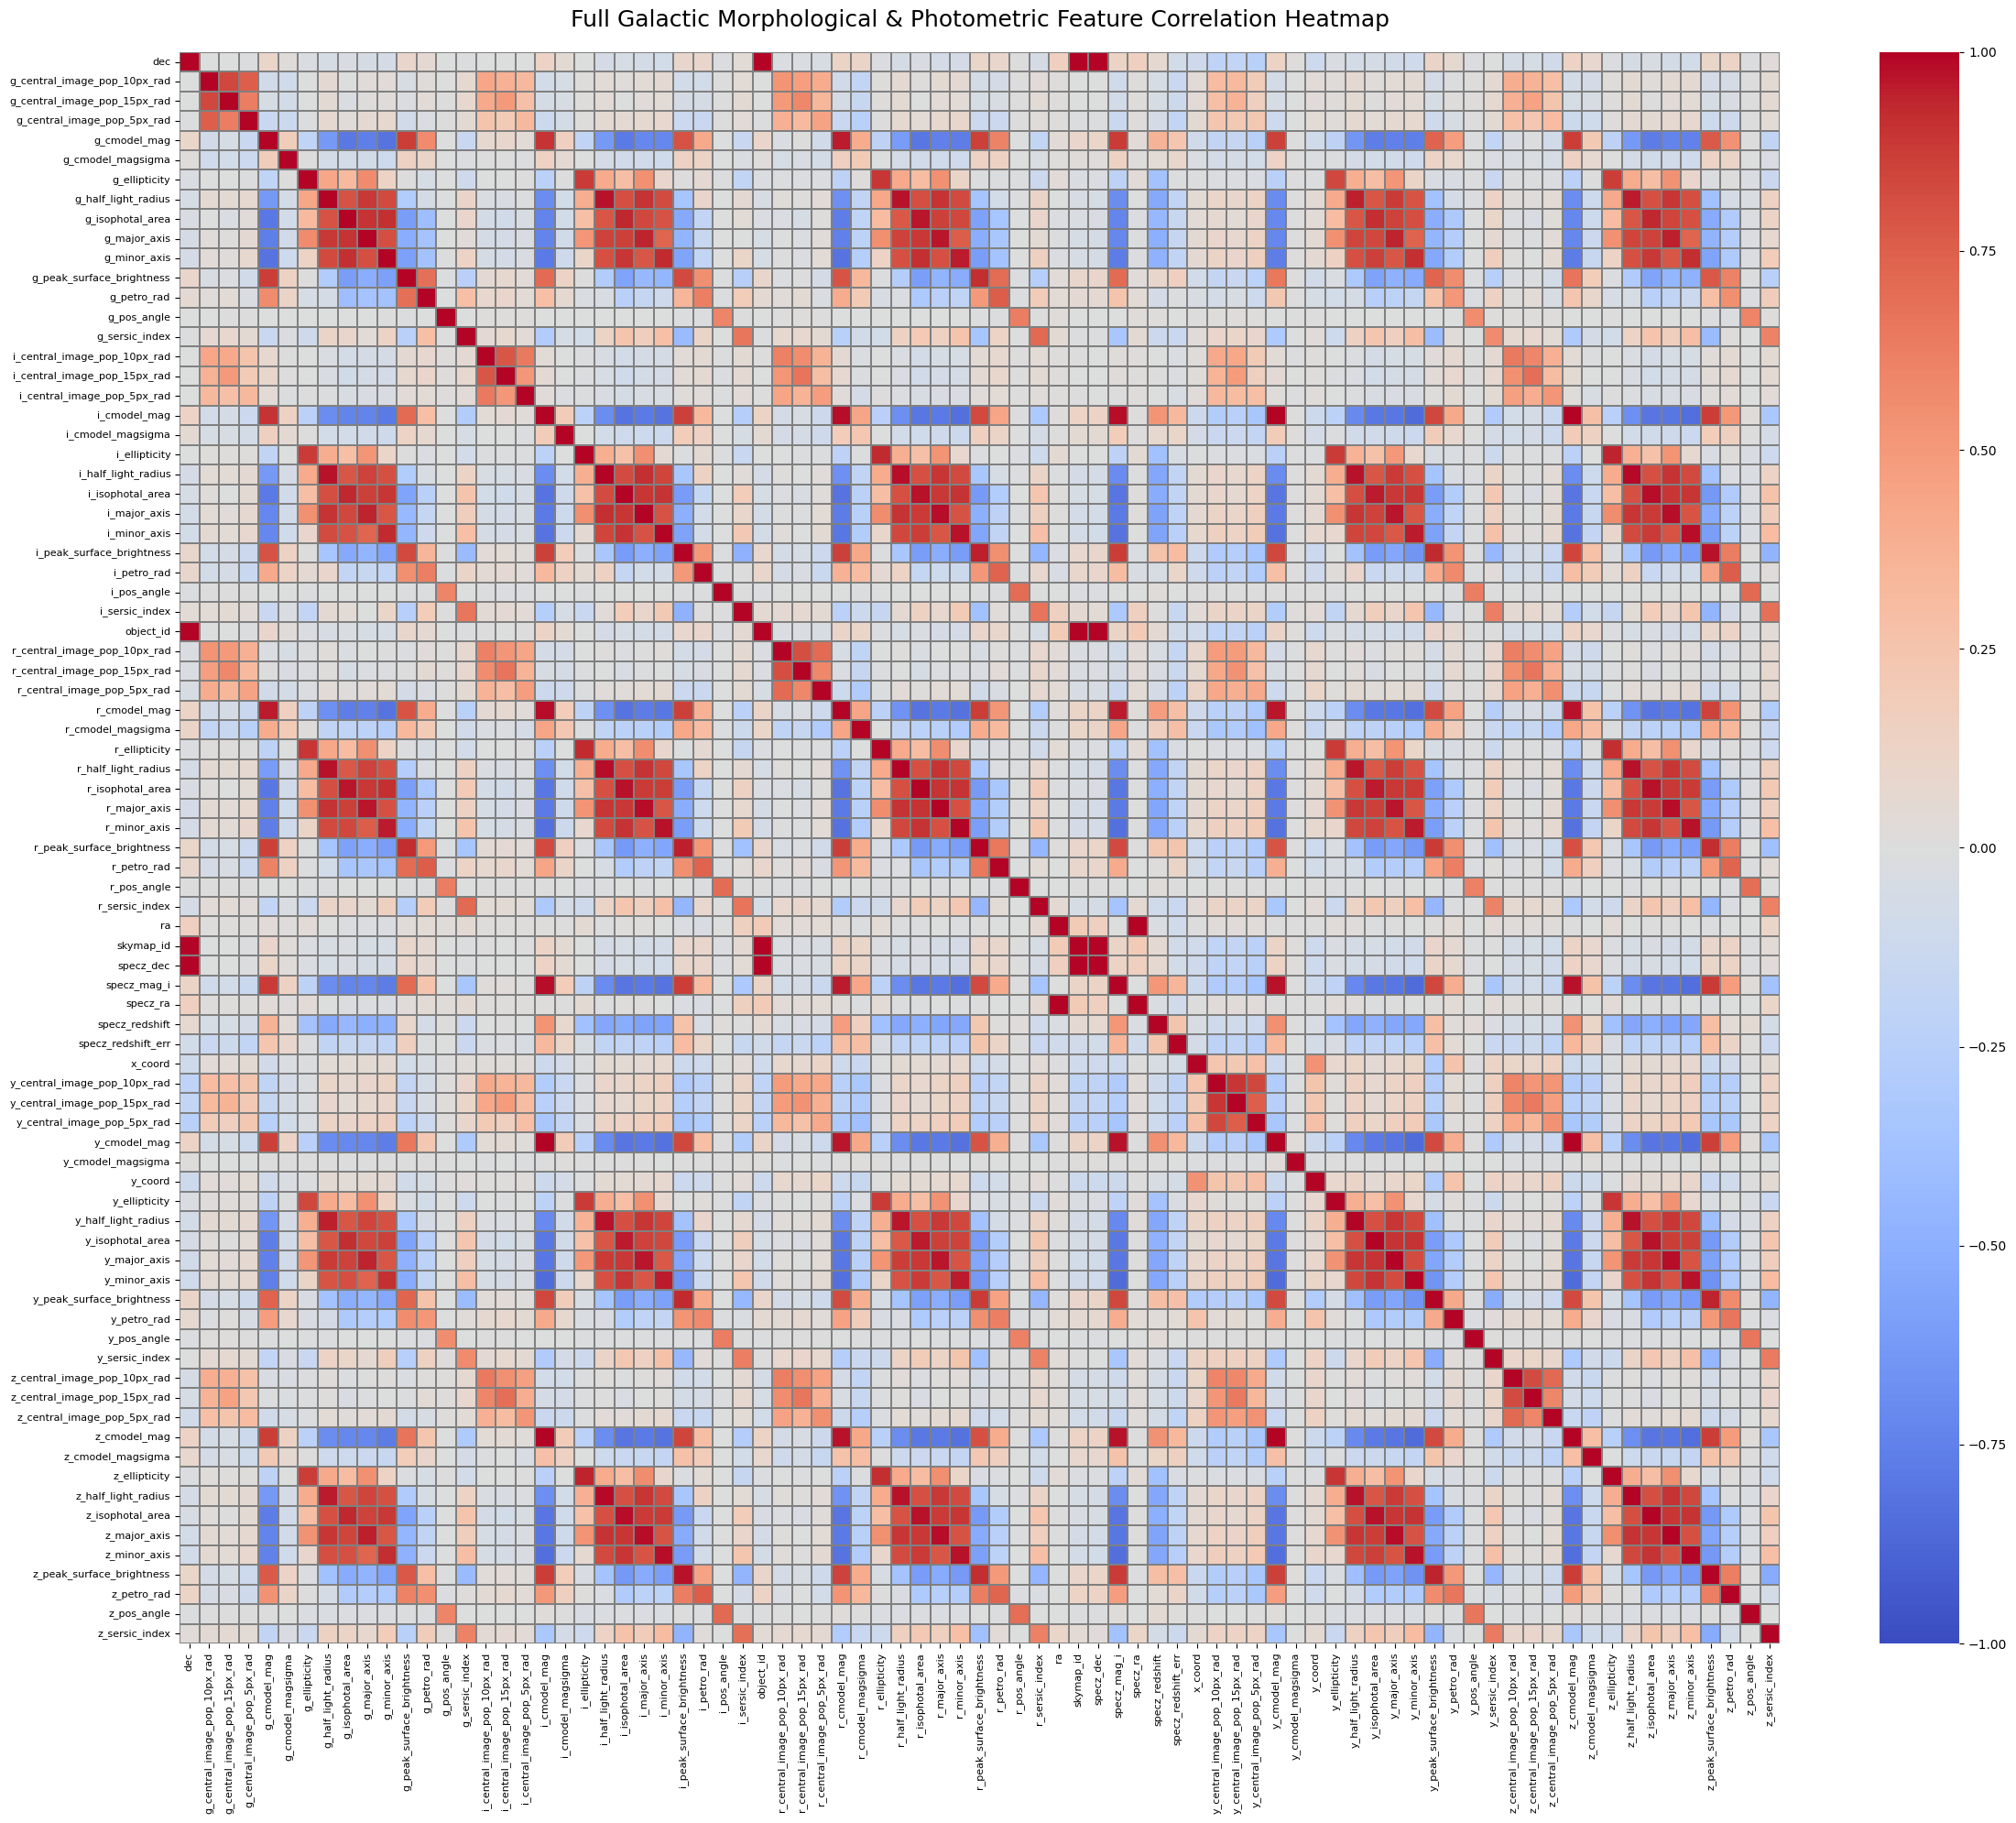

In [18]:

#Only keep features that have numbers
numeric_df = images_df.select_dtypes(include=['number'])
#Compute correlation matrix of all numeric features
full_corr_matrix = numeric_df.corr()
#create heatmap of the correlation matrix
plt.figure(figsize=(24, 20))
sns.heatmap(
    full_corr_matrix, 
    cmap="coolwarm",  
    vmin=-1, vmax=1,
    annot=False, 
    linewidths=0.05,
    linecolor='gray'
)

plt.title("Full Galactic Morphological & Photometric Feature Correlation Heatmap", fontsize=18, pad=20)
# vscode just filled in that title and it sounded cool
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Kind of insane looking, but very cool. Now just looking at a subset of the features, since there seems to be the same pattern accross different sets (g, i, r, y, z)



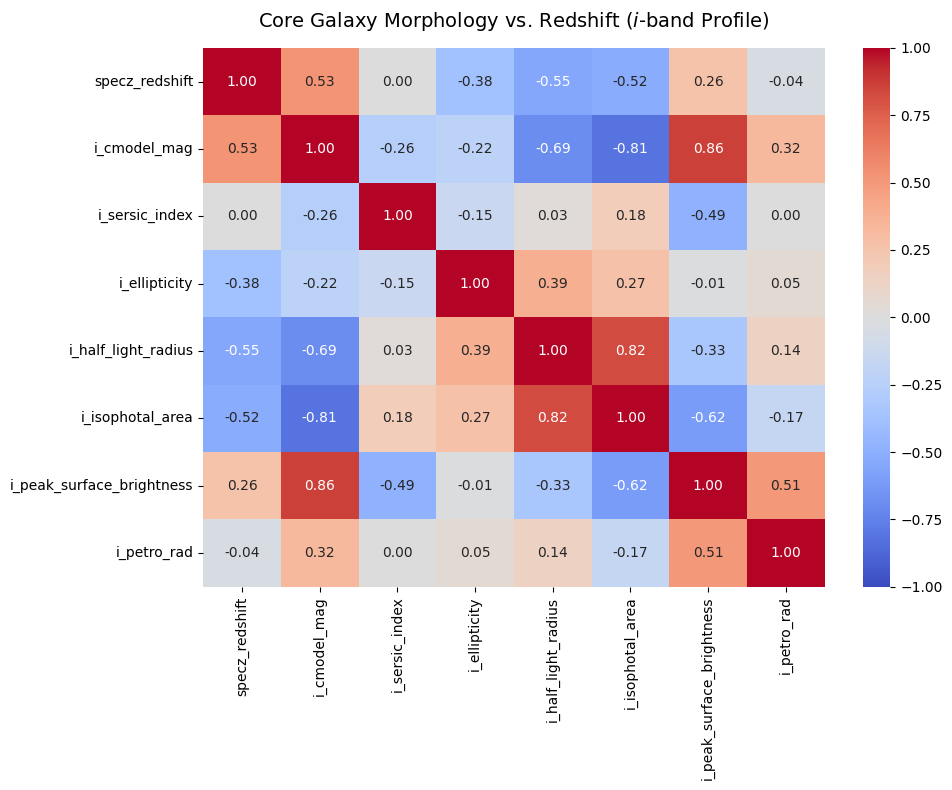

In [19]:
#I am pretty sure the i- band features are the most relevant to the redshift, so I will make a subset of those for a more focused correlation analysis. I will also include the spectroscopic redshift for this analysis, since that is the most accurate redshift measurement we have and is what we are trying to predict with our model.

morphology_subset = [
    'specz_redshift', 
    'i_cmodel_mag', 
    'i_sersic_index', 
    'i_ellipticity', 
    'i_half_light_radius', 
    'i_isophotal_area', 
    'i_peak_surface_brightness',
    'i_petro_rad'
]

plt.figure(figsize=(10, 8))
sns.heatmap(images_df[morphology_subset].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Core Galaxy Morphology vs. Redshift ($i$-band Profile)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Making some violin plots or boxplots to compare the different bands (g, r, i, z, y).)

C:\Users\smenc\AppData\Local\Temp\ipykernel_27104\2190550599.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


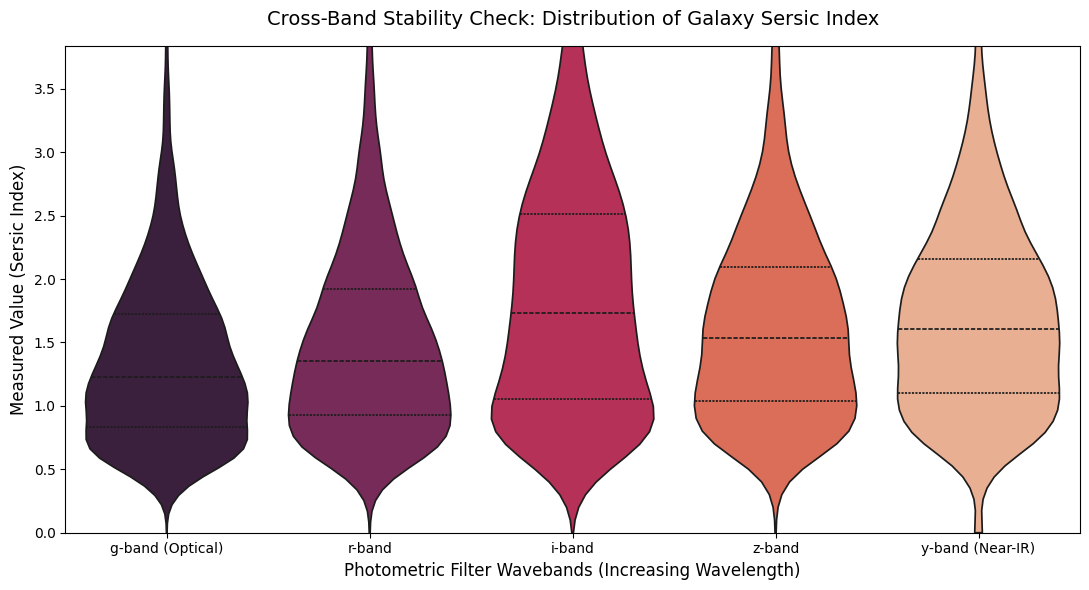

In [135]:
#'half_light_radius', 'sersic_index', 'ellipticity', 'cmodel_mag'
feature_to_plot = 'sersic_index'

band_mapping = {
    f'g_{feature_to_plot}': 'g-band (Optical)',
    f'r_{feature_to_plot}': 'r-band',
    f'i_{feature_to_plot}': 'i-band',
    f'z_{feature_to_plot}': 'z-band',
    f'y_{feature_to_plot}': 'y-band (Near-IR)'
}

#use the band mapping to filter the columns in the dataframe, and only keep those that are present in the dataframe
valid_columns = [col for col in band_mapping.keys() if col in images_df.columns]

sampled_df = images_df[valid_columns].sample(min(10000, len(images_df)))
    
# Melt the wide DataFrame into a long-form structure for Seaborn compatibility
long_df = pd.melt(sampled_df, value_vars=valid_columns, var_name='Filter Band', value_name='Value')
long_df['Filter Band'] = long_df['Filter Band'].map(band_mapping)
    
plt.figure(figsize=(11, 6))
    
# Violin plots show both the box-plot summary stats and the raw kernel density probability
# violin plots are great for showing the distribution of values across different categories, 
# and they can reveal differences in the shape of the distribution that might not be apparent in box plots alone. 
# The 'inner' parameter set to 'quartile' adds lines for the median and quartiles, while 'cut=0' ensures that the violin shape is limited to the range of observed data, 
# preventing it from extending into areas with no data.
sns.violinplot(
    data=long_df, 
    x='Filter Band', 
    y='Value', 
    palette='rocket', 
    inner='quartile', 
    cut=0   #limits the violin shape strictly to observed data min/max
)
    

y_max = long_df['Value'].quantile(0.98)
plt.ylim(0, y_max)
    
clean_title = feature_to_plot.replace('_', ' ').title()
plt.title(f"Cross-Band Stability Check: Distribution of Galaxy {clean_title}", fontsize=14, pad=15)
plt.xlabel("Photometric Filter Wavebands (Increasing Wavelength)", fontsize=12)
plt.ylabel(f"Measured Value ({clean_title})", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\smenc\AppData\Local\Temp\ipykernel_27104\3712383666.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


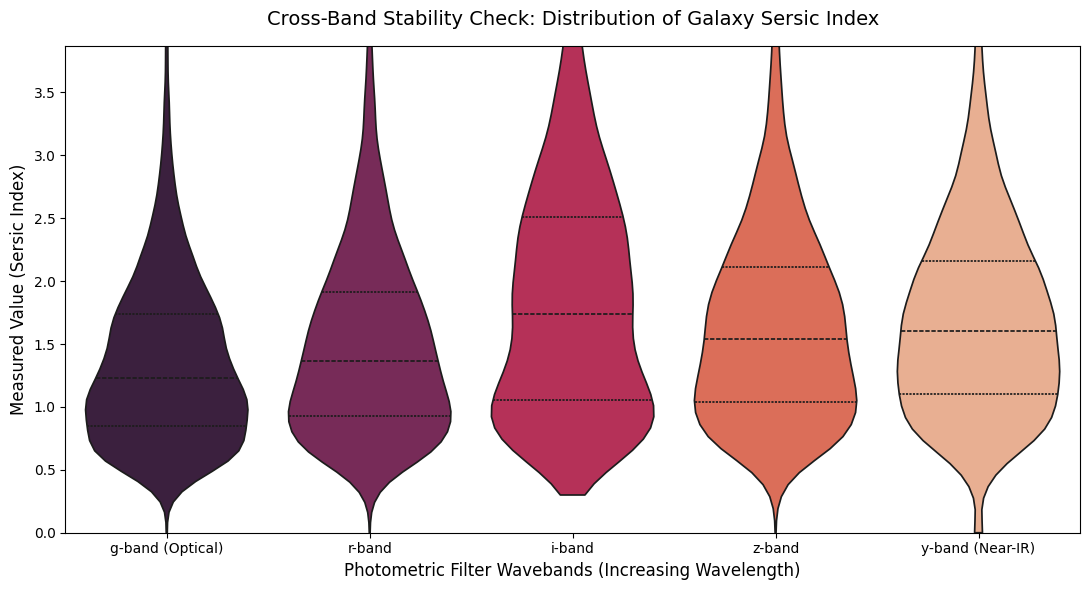

In [21]:
#'half_light_radius', 'sersic_index', 'ellipticity', 'cmodel_mag'
feature_to_plot = 'sersic_index'
# sersic index is a measure of the concentration of a galaxy's light profile, 
# and it can provide insights into the galaxy's morphology and structure. 
# By plotting the distribution of the sersic index across different photometric bands, 
# we can check for consistency in the measurements and identify any potential issues with the data 
# or the measurement process. If the distributions are similar across bands, 
# it suggests that the sersic index is being measured reliably regardless of the wavelength, 
# which is important for our model's ability to learn from these features effectively.

band_mapping = {
    f'g_{feature_to_plot}': 'g-band (Optical)',
    f'r_{feature_to_plot}': 'r-band',
    f'i_{feature_to_plot}': 'i-band',
    f'z_{feature_to_plot}': 'z-band',
    f'y_{feature_to_plot}': 'y-band (Near-IR)'
}

#use the band mapping to filter the columns in the dataframe, and only keep those that are present in the dataframe
valid_columns = [col for col in band_mapping.keys() if col in images_df.columns]

sampled_df = images_df[valid_columns].sample(min(10000, len(images_df)))
    
# Melt the wide DataFrame into a long-form structure for Seaborn compatibility
long_df = pd.melt(sampled_df, value_vars=valid_columns, var_name='Filter Band', value_name='Value')
long_df['Filter Band'] = long_df['Filter Band'].map(band_mapping)
    
plt.figure(figsize=(11, 6))

sns.violinplot(
    data=long_df, 
    x='Filter Band', 
    y='Value', 
    palette='rocket', 
    inner='quartile', 
    cut=0   #limits the violin shape strictly to observed data min/max
)
    

y_max = long_df['Value'].quantile(0.98)
plt.ylim(0, y_max)
    
clean_title = feature_to_plot.replace('_', ' ').title()
plt.title(f"Cross-Band Stability Check: Distribution of Galaxy {clean_title}", fontsize=14, pad=15)
plt.xlabel("Photometric Filter Wavebands (Increasing Wavelength)", fontsize=12)
plt.ylabel(f"Measured Value ({clean_title})", fontsize=12)
plt.tight_layout()
plt.show()

# Useful to check how all sersic index values are distributed across the dataset, and to identify any potential outliers or issues with the data.
# This way when we choose which sersic index to use for our model, we can be confident that it is a stable and reliable feature across the different photometric bands.

## JWST Dataset

In [22]:
# Image Samples
# This code is from the MultimodalUniverse Github repository, which is the source of our dataset. 
# It loads the dataset using Hugging Face's `datasets` library and retrieves an example to inspect its structure.
# Collab notebook: https://colab.research.google.com/github/MultimodalUniverse/MultimodalUniverse/blob/main/notebooks/getting_started.ipynb

dset_ls = load_dataset("MultimodalUniverse/jwst", 
                       streaming=True, 
                       split="train")
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

In [23]:
example = next(dset_iterator)

In [24]:
example.keys()

dict_keys(['image', 'mag_auto', 'flux_radius', 'flux_auto', 'fluxerr_auto', 'cxx_image', 'cyy_image', 'cxy_image', 'object_id'])

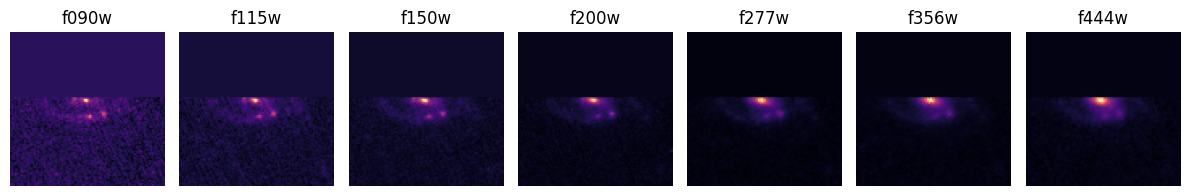

In [25]:
plt.figure(figsize=(12, 5))
n_bands = len(example["image"]["band"])
for i, b in enumerate(example["image"]["band"]):
    plt.subplot(1, n_bands, i + 1)
    plt.title(f"{b}")
    plt.imshow(example["image"]["flux"][i], cmap="magma")
    plt.axis("off")
plt.tight_layout()


Info about the photometric filters used in the JWST dataset: https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-instrumentation/miri-filters-and-dispersers#gsc.tab=0

# Adapting a CNN for 5 channels

Standard pre-trained CNNs expect 3 channels (RGB). GalaxyML data has 5 channels (u, g, r, i, z). We will modify a standard `ResNet18` to accept 5 channels

In [26]:
def get_galaxy_model():
    # Start with an untrained ResNet-18 model
    model = models.resnet18(weights=None)  
    
    # Modify the first convolutional layer to accept 5 input channels instead of 3
    model.conv1 = nn.Conv2d(
        in_channels=5, 
        out_channels=64, 
        kernel_size=7, 
        stride=2, 
        padding=3, 
        bias=False
    )
    
    # Modify the final fully connected layer to output the number of classes (e.g., 10)
    num_classes = 3  # Update this based on your specific classification task
    model.fc = nn.Linear(
        in_features=model.fc.in_features, 
        out_features=num_classes
    )
    
    return model

In [27]:
model = get_galaxy_model()
sample_input = torch.randn(2, 5, 127, 127)  # Batch size of 2, 5 channels, 127x127 image
output = model(sample_input)
print("Output shape:", output.shape)  # Should be (2, num_classes)

Output shape: torch.Size([2, 3])


# Galaxy Mapping

In [28]:
# Load Galaxy labels from MultimodalUniverse Github repository

gz10 = load_dataset("MultimodalUniverse/gz10", split="train")
gz10_df = gz10.remove_columns(["rgb_image"]).to_pandas()
print(gz10_df.columns)
gz10_df.head()


Index(['gz10_label', 'redshift', 'object_id', 'rgb_pixel_scale'], dtype='str')


,gz10_label,redshift,object_id,rgb_pixel_scale
0,0,0.072587,904,0.262
1,1,0.134578,1558,0.262
2,1,0.129557,1768,0.262
3,2,0.127358,4520,0.262
4,4,0.041413,7653,0.262


In [29]:
# Refer to this link here
# https://github.com/henrysky/Galaxy10/blob/master/README.rst
# gz10 mappings to galaxy type
"""
Galaxy10 dataset (17736 images)
├── Class 0 (1081 images): Disturbed Galaxies
├── Class 1 (1853 images): Merging Galaxies
├── Class 2 (2645 images): Round Smooth Galaxies
├── Class 3 (2027 images): In-between Round Smooth Galaxies
├── Class 4 ( 334 images): Cigar Shaped Smooth Galaxies
├── Class 5 (2043 images): Barred Spiral Galaxies
├── Class 6 (1829 images): Unbarred Tight Spiral Galaxies
├── Class 7 (2628 images): Unbarred Loose Spiral Galaxies
├── Class 8 (1423 images): Edge-on Galaxies without Bulge
└── Class 9 (1873 images): Edge-on Galaxies with Bulge
"""

'\nGalaxy10 dataset (17736 images)\n├── Class 0 (1081 images): Disturbed Galaxies\n├── Class 1 (1853 images): Merging Galaxies\n├── Class 2 (2645 images): Round Smooth Galaxies\n├── Class 3 (2027 images): In-between Round Smooth Galaxies\n├── Class 4 ( 334 images): Cigar Shaped Smooth Galaxies\n├── Class 5 (2043 images): Barred Spiral Galaxies\n├── Class 6 (1829 images): Unbarred Tight Spiral Galaxies\n├── Class 7 (2628 images): Unbarred Loose Spiral Galaxies\n├── Class 8 (1423 images): Edge-on Galaxies without Bulge\n└── Class 9 (1873 images): Edge-on Galaxies with Bulge\n'

In [30]:
print(gz10.features)
print(gz10.info)

{'gz10_label': Value('int32'), 'redshift': Value('float32'), 'object_id': Value('string'), 'rgb_image': Image(mode=None, decode=True), 'rgb_pixel_scale': Value('float32')}
DatasetInfo(features={'gz10_label': Value('int32'), 'redshift': Value('float32'), 'object_id': Value('string'), 'rgb_image': Image(mode=None, decode=True), 'rgb_pixel_scale': Value('float32')}, builder_name='parquet', dataset_name='gz10', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=2542804184, num_examples=17736, shard_lengths=[3600, 3400, 3568, 3500, 3668], dataset_name='gz10')}, download_size=2535620959, dataset_size=2542804184, size_in_bytes=5078425143)


In [31]:
print(images_df['object_id'].head(20))
print(gz10_df['object_id'].head(20))

0     36407046198791272
1     36407046198803509
2     36407050493759629
3     36407050493760107
4     36407050493771757
5     36407050493773284
6     36407050493775097
7     36407050493775245
8     36407054788740340
9     36407054788741196
10    36407054788744371
11    36407059083690887
12    36407059083690946
13    36407059083707244
14    36407059083707750
15    36407059083710797
16    36407183637742656
17    36407187932710595
18    36407187932723873
19    36407192227679589
Name: object_id, dtype: int64
0       904
1      1558
2      1768
3      4520
4      7653
5     14778
6     14859
7     15508
8     16472
9     16998
10    10744
11     1522
12     7645
13     8466
14    12404
15    16955
16     8485
17      330
18     3359
19     3360
Name: object_id, dtype: str


In [32]:
df = images_df.copy()
df = df.dropna(subset=['i_sersic_index'])
# we need to determine a cutoff value to determine disk vs elliptical
# not sure what the exact cutoff should be
cutoff = 4
df['galaxy_type'] = (df['i_sersic_index'] >= cutoff).astype(int)

print(df['galaxy_type'].value_counts())
print(df['galaxy_type'])

galaxy_type
0    196946
1      7627
Name: count, dtype: int64
0         0
1         0
2         0
3         0
4         0
         ..
204568    0
204569    1
204570    0
204571    0
204572    0
Name: galaxy_type, Length: 204573, dtype: int64


In [84]:
#ADDING IRREGULAR CLASS BASED ON SERSIC INDEX < 1
df = images_df.copy()
df = df.dropna(subset=['i_sersic_index'])

# 3 classes based on i_sersic_index:
# 0 = elliptical (>= 4), 1 = spiral (1 to 4), 2 = irregular (< 1)
df['galaxy_type'] = np.select(
    [
        df['i_sersic_index'] < 1,
        df['i_sersic_index'] >= 4,
    ],
    [2, 0],
    default=1
)

print(df['galaxy_type'].value_counts())
print(df['galaxy_type'])

galaxy_type
1    150436
2     46510
0      7627
Name: count, dtype: int64
0         1
1         1
2         1
3         1
4         1
         ..
204568    1
204569    0
204570    1
204571    2
204572    2
Name: galaxy_type, Length: 204573, dtype: int64


galaxy_type
0      7627
1    150436
2     46510
Name: count, dtype: int64


<Axes: xlabel='galaxy_type'>

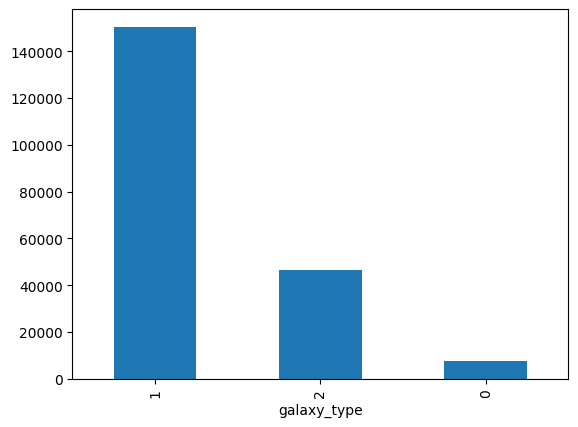

In [85]:
#Distribution of galaxy types in the dataset
counts = df['galaxy_type'].value_counts().sort_index()
print(counts)
df['galaxy_type'].value_counts().plot(kind='bar')

In [86]:
# photometric filters
features = [
    'g_cmodel_mag',
    'r_cmodel_mag',
    'i_cmodel_mag',
    'z_cmodel_mag',
    'y_cmodel_mag'
]

model_df = df[features + ['galaxy_type']].dropna()

X = model_df[features]
y = model_df['galaxy_type']

In [87]:
model_df.head()

,g_cmodel_mag,r_cmodel_mag,i_cmodel_mag,z_cmodel_mag,y_cmodel_mag,galaxy_type
0,20.162785,20.303240,20.003777,19.592779,19.839014,1
1,20.320715,18.924778,18.247103,17.874811,17.614677,1
2,21.629736,19.881702,18.808056,18.372108,18.164425,1
3,21.448307,21.582899,21.402744,20.637022,20.885055,1
4,21.827169,20.187965,19.282352,18.911262,18.741877,1


In [88]:
# Attempt to merge images_df with galaxyzoo based on dec and ra
zoo_df = pd.read_csv("data/zoo2MainSpecz.csv")

In [89]:
zoo_df.head()

,specobjid,dr8objid,dr7objid,ra,dec,rastring,decstring,sample,gz2class,total_classifications,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,1.802675e+18,NaN,588017703996096547,160.99040,11.703790,10:43:57.70,+11:42:13.6,original,SBb?t,44,...,0.225,0.225,0.225,0,10,10.0,0.250,0.250,0.250,0
1,1.992984e+18,NaN,587738569780428805,192.41083,15.164207,12:49:38.60,+15:09:51.1,original,Ser,45,...,0.000,0.000,0.000,0,0,0.0,0.000,0.000,0.000,0
2,1.489569e+18,NaN,587735695913320507,210.80220,54.348953,14:03:12.53,+54:20:56.2,original,Sc+t,46,...,0.651,0.651,0.651,0,3,3.0,0.070,0.070,0.070,0
3,2.924084e+18,1.237668e+18,587742775634624545,185.30342,18.382704,12:21:12.82,+18:22:57.7,original,SBc(r),45,...,0.071,0.071,0.071,0,6,6.0,0.429,0.429,0.429,0
4,1.387165e+18,1.237658e+18,587732769983889439,187.36679,8.749928,12:29:28.03,+08:44:59.7,extra,Ser,49,...,0.000,0.000,0.000,0,1,1.0,1.000,1.000,1.000,0


In [90]:
zoo_df.columns.tolist()[:15]

['specobjid',
 'dr8objid',
 'dr7objid',
 'ra',
 'dec',
 'rastring',
 'decstring',
 'sample',
 'gz2class',
 'total_classifications',
 'total_votes',
 't01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction']

In [91]:
zoo_features = [
    'dec',
    'ra',
    'rastring',
    'decstring',
    'gz2class'
]
 
zoo_df_small = zoo_df[zoo_features]
zoo_df_small.head()    

,dec,ra,rastring,decstring,gz2class
0,11.703790,160.99040,10:43:57.70,+11:42:13.6,SBb?t
1,15.164207,192.41083,12:49:38.60,+15:09:51.1,Ser
2,54.348953,210.80220,14:03:12.53,+54:20:56.2,Sc+t
3,18.382704,185.30342,12:21:12.82,+18:22:57.7,SBc(r)
4,8.749928,187.36679,12:29:28.03,+08:44:59.7,Ser


In [92]:
zoo_dec = zoo_df_small['dec']
zoo_ra = zoo_df_small['ra']

In [93]:
images_df_dec = images_df['dec']
images_df_ra = images_df['ra']

In [94]:
# Use astropy to cross-match the two catalogs based on their celestial coordinates (RA and Dec) 
from astropy.coordinates import SkyCoord
from astropy import units as u

In [95]:
sample_coords = SkyCoord(ra=images_df["ra"].values*u.degree, dec=images_df["dec"].values*u.degree)
zoo_coords = SkyCoord(ra=zoo_df["ra"].values*u.degree, dec=zoo_df["dec"].values*u.degree)

# Match galaxies to its nearest neighbor in the zoo catalog
idx, d2d, d3d = sample_coords.match_to_catalog_sky(zoo_coords)

# Filter out matches that are too far away
max_separation = 2.0 * u.arcsec  # Adjust this threshold based on the expected positional accuracy
matches = d2d < max_separation

# Create a DataFrame of matched galaxies
matched_df = pd.DataFrame({
    "image_idx": np.where(matches)[0],
    "zoo_idx": idx[matches],
    'image_ra': images_df['ra'].values[matches],
    'image_dec': images_df['dec'].values[matches],
    'zoo_ra': zoo_df['ra'].values[idx[matches]],
    'zoo_dec': zoo_df['dec'].values[idx[matches]],
    'separation': d2d[matches].arcsec
})

print(f"Number of matched galaxies: {len(matched_df)}")
print(matched_df.head())

Number of matched galaxies: 5538
   image_idx  zoo_idx    image_ra  image_dec     zoo_ra   zoo_dec  separation
0      29783   238605  173.293360  -1.488138  173.29337 -1.488162    0.096143
1      29788   109631  173.161750  -2.006866  173.16174 -2.006873    0.044243
2      29791   104581  173.144076  -1.910295  173.14406 -1.910292    0.059871
3      29799   239183  173.202903  -1.641754  173.20290 -1.641783    0.103360
4      29810   140939  174.724632  -2.089508  174.72462 -2.089508    0.044021


In [96]:
# Pull only the zoo columns you want
zoo_labels = zoo_df[["gz2class"]].reset_index().rename(columns={"index": "zoo_idx"})

# Merge match info with zoo labels
matched_with_labels = matched_df.merge(zoo_labels, on="zoo_idx", how="left")

matched_with_labels.head()


,image_idx,zoo_idx,image_ra,image_dec,zoo_ra,zoo_dec,separation,gz2class
0,29783,238605,173.293360,-1.488138,173.29337,-1.488162,0.096143,Sc?t
1,29788,109631,173.161750,-2.006866,173.16174,-2.006873,0.044243,Sb2t
2,29791,104581,173.144076,-1.910295,173.14406,-1.910292,0.059871,Sc?m
3,29799,239183,173.202903,-1.641754,173.20290,-1.641783,0.103360,Sen
4,29810,140939,174.724632,-2.089508,174.72462,-2.089508,0.044021,Ser


In [97]:
images_with_idx = images_df.reset_index().rename(columns={"index": "image_idx"})

images_labeled = images_with_idx.merge(
    matched_with_labels[["image_idx", "gz2class", "separation"]],
    on="image_idx",
    how="left",
)

images_labeled.head()


,image_idx,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,...,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,gz2class,separation
0,0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,...,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146,NaN,NaN
1,1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,...,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576,NaN,NaN
2,2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,...,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096,NaN,NaN
3,3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,...,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943,NaN,NaN
4,4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,...,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187,NaN,NaN


In [98]:
images_labeled['gz2class'].value_counts()

gz2class
Er         870
Ei         817
Sb         435
Sc         427
Ser        333
          ... 
Sb3l         1
Sa(d)        1
Ec(o)        1
Sd?l(i)      1
Sb+m         1
Name: count, Length: 227, dtype: int64

In [99]:
images_labeled_clean = images_labeled.dropna(subset=['gz2class'])

In [100]:
images_labeled_clean.head()

,image_idx,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,...,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,gz2class,separation
29783,29783,"b'(-204784.265625, 24080.68359375, -5356.69287...",-1.488138,1,1,1,17.735281,0.000706,0.472,14.519,...,13.928,2985.0,15.135,7.995,-8.2591,5.28,-41.58,1.007,Sc?t,0.096143
29788,29788,"b'(-204671.875, 24544.234375, -7223.24072265625)'",-2.006866,1,1,1,17.208687,0.000557,0.471,12.845,...,12.053,2145.0,12.136,6.760,-8.8767,5.94,-14.62,1.637,Sb2t,0.044243
29791,29791,"b'(-204676.09375, 24608.78515625, -6875.787109...",-1.910295,1,1,1,18.474453,0.001769,0.300,21.335,...,19.218,1949.0,12.582,9.017,-7.4077,8.58,46.19,2.157,Sc?m,0.059871
29799,29799,"b'(-204731, 24402.173828125, -5909.5068359375)'",-1.641754,1,1,1,17.853600,0.000837,0.669,18.452,...,17.046,2888.0,20.103,6.638,-7.4197,7.26,87.59,1.563,Sen,0.103360
29810,29810,"b'(-205254.5625, 18951.892578125, -7520.560546...",-2.089508,1,1,1,17.087647,0.000892,0.713,15.722,...,13.368,3561.0,19.923,6.080,-8.9362,5.28,38.69,1.563,Ser,0.044021


In [101]:
images_labeled_clean.info()

<class 'pandas.DataFrame'>
Index: 5538 entries, 29783 to 204548
Data columns (total 87 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   image_idx                     5538 non-null   int64  
 1   coord                         5538 non-null   str    
 2   dec                           5538 non-null   float64
 3   g_central_image_pop_10px_rad  5538 non-null   int64  
 4   g_central_image_pop_15px_rad  5538 non-null   int64  
 5   g_central_image_pop_5px_rad   5538 non-null   int64  
 6   g_cmodel_mag                  5538 non-null   float64
 7   g_cmodel_magsigma             5538 non-null   float64
 8   g_ellipticity                 5538 non-null   float64
 9   g_half_light_radius           5538 non-null   float64
 10  g_isophotal_area              5538 non-null   float64
 11  g_major_axis                  5538 non-null   float64
 12  g_minor_axis                  5538 non-null   float64
 13  g_peak_surfac

In [102]:
# Build a model-ready dataframe using only rows with matched Zoo labels
train_df = images_labeled_clean.copy()

# Turn text class labels into numeric labels for ML
train_df["gz2_label"], class_names = pd.factorize(train_df["gz2class"])

print("Training rows with labels:", len(train_df))
print("Unique classes:", len(class_names))
print("\nClass mapping:")
for i, c in enumerate(class_names):
    print(f"{i}: {c}")

# Example feature set
feature_cols = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
    "g_sersic_index",
    "r_sersic_index",
    "i_sersic_index",
    "z_sersic_index",
    "y_sersic_index",
]

# Keep only features that actually exist in your dataframe
feature_cols = [c for c in feature_cols if c in train_df.columns]

X = train_df[feature_cols]
y = train_df["gz2_label"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Training rows with labels: 5538
Unique classes: 227

Class mapping:
0: Sc?t
1: Sb2t
2: Sc?m
3: Sen
4: Ser
5: Sen(i)
6: Sc
7: Sc2t
8: Sc2m
9: SBd4l(i)
10: Sb(m)
11: Ei
12: SBb2m
13: Sb?t
14: Er
15: Sb
16: SBc2m
17: SBa2m
18: Sb(o)
19: Ei(o)
20: Sc(r)
21: SBb
22: SBd
23: Sc(i)
24: SBc2l
25: Sb?m
26: SBc
27: Er(o)
28: Sc3t
29: Sb1t
30: Sc1m
31: Sa?t
32: Sc4t
33: Sc(o)
34: Sd?m
35: Ec
36: SBb(i)
37: Sb(d)
38: Er(m)
39: Seb
40: Sc+t
41: SBc?m
42: Sb2m
43: Sc2l
44: Sc1t
45: Sc?t(i)
46: Sc+t(m)
47: Sc2m(o)
48: Sc1t(m)
49: Sc2l(m)
50: Sb1m
51: Ei(i)
52: Sc2m(d)
53: Sb3m(o)
54: SBb(r)
55: Sd(i)
56: Sb(r)
57: Sd
58: Sc2l(i)
59: SBc?t
60: Sb3m
61: Sc3m
62: Sb3t(r)
63: Sa(i)
64: Sb?t(m)
65: SBb2m(r)
66: Sc1m(m)
67: Sd2l
68: SBb2l
69: Sb2t(d)
70: Sc4m(d)
71: Sb3t(m)
72: SBb?t
73: Sb2m(i)
74: Sb+t
75: SBc3m
76: SBc3t
77: Sb?t(r)
78: Sc1l(i)
79: SBb2t
80: Sc3m(i)
81: Ei(m)
82: Ser(m)
83: SBc?l(i)
84: A
85: Sb?l
86: Sb2t(m)
87: SBc2t
88: Sc(d)
89: Sb1t(i)
90: Sd?t
91: SBb+t
92: Sc?l
93: Sb2t(r)
94: Sb

## Logistic Regression

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: [9, 17, 36, 46, 47, 48, 53, 69, 70, 71, 83, 89, 91, 94, 97, 98, 103, 104, 109, 111, 115, 117, 120, 124, 133, 136, 137, 138, 140, 141, 142, 143, 144, 145, 152, 155, 159, 162, 163, 165, 168, 169, 171, 173, 174, 175, 181, 182, 183, 184, 185, 186, 188, 191, 195, 197, 198, 199, 200, 202, 203, 204, 205, 206, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226]

## Random Forest

In [114]:
#ADDING IRREGULAR CLASS BASED ON SERSIC INDEX < 1
rf_df = images_labeled_clean.copy()
rf_df = rf_df.dropna(subset=['i_sersic_index'])

# 3 classes based on i_sersic_index:
# 0 = elliptical (>= 4), 1 = spiral (1 to 4), 2 = irregular (< 1)
rf_df['galaxy_type'] = np.select(
    [
        rf_df['i_sersic_index'] < 1,
        rf_df['i_sersic_index'] >= 4,
    ],
    [2, 0],
    default=1
)

print(rf_df['galaxy_type'].value_counts())
print(rf_df['galaxy_type'])

galaxy_type
1    4278
2     833
0     427
Name: count, dtype: int64
29783     2
29788     1
29791     1
29799     1
29810     2
         ..
203178    1
204199    1
204276    2
204535    2
204548    1
Name: galaxy_type, Length: 5538, dtype: int64


In [115]:
# Build a model-ready dataframe using only rows with matched Zoo labels
rf_train_df = rf_df.copy()

print("Training rows with labels:", len(rf_train_df))
print("Unique classes:", len(class_names))
print("\nClass mapping:")
for i, c in enumerate(class_names):
    print(f"{i}: {c}")

# Example feature set
feature_cols = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
    "g_sersic_index",
    "r_sersic_index",
    "i_sersic_index",
    "z_sersic_index",
    "y_sersic_index",
]

# Keep only features that actually exist in your dataframe
feature_cols = [c for c in feature_cols if c in rf_train_df.columns]

X = rf_train_df[feature_cols]
y = rf_train_df["galaxy_type"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Training rows with labels: 5538
Unique classes: 227

Class mapping:
0: Sc?t
1: Sb2t
2: Sc?m
3: Sen
4: Ser
5: Sen(i)
6: Sc
7: Sc2t
8: Sc2m
9: SBd4l(i)
10: Sb(m)
11: Ei
12: SBb2m
13: Sb?t
14: Er
15: Sb
16: SBc2m
17: SBa2m
18: Sb(o)
19: Ei(o)
20: Sc(r)
21: SBb
22: SBd
23: Sc(i)
24: SBc2l
25: Sb?m
26: SBc
27: Er(o)
28: Sc3t
29: Sb1t
30: Sc1m
31: Sa?t
32: Sc4t
33: Sc(o)
34: Sd?m
35: Ec
36: SBb(i)
37: Sb(d)
38: Er(m)
39: Seb
40: Sc+t
41: SBc?m
42: Sb2m
43: Sc2l
44: Sc1t
45: Sc?t(i)
46: Sc+t(m)
47: Sc2m(o)
48: Sc1t(m)
49: Sc2l(m)
50: Sb1m
51: Ei(i)
52: Sc2m(d)
53: Sb3m(o)
54: SBb(r)
55: Sd(i)
56: Sb(r)
57: Sd
58: Sc2l(i)
59: SBc?t
60: Sb3m
61: Sc3m
62: Sb3t(r)
63: Sa(i)
64: Sb?t(m)
65: SBb2m(r)
66: Sc1m(m)
67: Sd2l
68: SBb2l
69: Sb2t(d)
70: Sc4m(d)
71: Sb3t(m)
72: SBb?t
73: Sb2m(i)
74: Sb+t
75: SBc3m
76: SBc3t
77: Sb?t(r)
78: Sc1l(i)
79: SBb2t
80: Sc3m(i)
81: Ei(m)
82: Ser(m)
83: SBc?l(i)
84: A
85: Sb?l
86: Sb2t(m)
87: SBc2t
88: Sc(d)
89: Sb1t(i)
90: Sd?t
91: SBb+t
92: Sc?l
93: Sb2t(r)
94: Sb

In [117]:
y_train.value_counts()

galaxy_type
1    3422
2     666
0     342
Name: count, dtype: int64

In [125]:
# Rannndom Forest Classifier 
# usefuk for feature importance and non-linear relationships, but can be prone to overfitting if not tuned properly.
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
#Saving this for when we have 3 classes, but it would shown error right now because we only have 2 classes in our current dataset.
"""
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf, 
    display_labels=['Spiral', 'Elliptical', 'Irregular'] 
)


disp.plot(cmap='Purples', values_format='d')
plt.title("Random Forest: Galaxy Morphology Classification Matrix", fontsize=13, pad=12)
plt.grid(False) 
plt.tight_layout()
plt.show()
"""

              precision    recall  f1-score   support

           0       0.09      0.42      0.15      1525
           1       0.91      0.60      0.72     30088
           2       0.55      0.82      0.66      9302

    accuracy                           0.64     40915
   macro avg       0.52      0.61      0.51     40915
weighted avg       0.80      0.64      0.69     40915



'\ncm_rf = confusion_matrix(y_test, y_pred_rf)\nplt.figure(figsize=(6, 5))\ndisp = ConfusionMatrixDisplay(\n    confusion_matrix=cm_rf, \n    display_labels=[\'Spiral\', \'Elliptical\', \'Irregular\'] \n)\n\n\ndisp.plot(cmap=\'Purples\', values_format=\'d\')\nplt.title("Random Forest: Galaxy Morphology Classification Matrix", fontsize=13, pad=12)\nplt.grid(False) \nplt.tight_layout()\nplt.show()\n'

In [126]:
X_train.head()

,g_cmodel_mag,r_cmodel_mag,i_cmodel_mag,z_cmodel_mag,y_cmodel_mag
14071,22.584532,21.744446,20.844933,20.780529,20.203842
177388,23.199471,21.449959,20.206133,19.699104,19.461964
55050,20.492535,19.725147,19.217335,18.871738,18.600468
44881,21.611027,19.918785,19.064751,18.700708,18.490047
200315,25.137669,24.230478,23.102903,22.501961,22.194269


In [127]:
y_train.unique()

array([1, 2, 0])

In [128]:
# Check for a class imbalance in the training data
feature_cols = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
]
print(model_df["galaxy_type"].value_counts(normalize=True))
 
X = model_df[feature_cols]
y = model_df["galaxy_type"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


galaxy_type
1    0.735366
2    0.227352
0    0.037283
Name: proportion, dtype: float64


In [129]:
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")

Train accuracy: 0.672 | Test accuracy: 0.643


Since class 0 Elliptical is such a small portion of the data, we could use bootstrapping to manage the class imbalance

In [133]:
# Use class_weight='balanced_subsample' in the Random Forest to automatically adjust weights for each class based on their frequency in the training data, 
# which can help mitigate the effects of class imbalance and improve model performance on minority classes.

rf_boots = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf_boots.fit(X_train, y_train)

y_pred_rf_boots = rf_boots.predict(X_test)

print(classification_report(y_test, y_pred_rf_boots))

              precision    recall  f1-score   support

           0       0.10      0.35      0.15      1525
           1       0.91      0.65      0.76     30088
           2       0.55      0.82      0.66      9302

    accuracy                           0.68     40915
   macro avg       0.52      0.61      0.52     40915
weighted avg       0.80      0.68      0.71     40915



In [134]:
train_acc = accuracy_score(y_train, rf_boots.predict(X_train))
test_acc = accuracy_score(y_test, rf_boots.predict(X_test))
print(f"Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")

Train accuracy: 0.708 | Test accuracy: 0.678


Bootsrtapping brought up both the train and test accuracies! Recall went up for 1 and 2, but down for 0. 
This is likely because the model is now paying more attention to the minority classes (spiral and irregular) at the expense of the majority class (elliptical).

## Unsupervised ML Model

My idea rn is to cluster galaxies on their multi-band morphology/photometry profile and then use those clusters as a feature for classification, or to see if they correspond to known morphological classes.

In [153]:
rf_df.columns.tolist()

['image_idx',
 'coord',
 'dec',
 'g_central_image_pop_10px_rad',
 'g_central_image_pop_15px_rad',
 'g_central_image_pop_5px_rad',
 'g_cmodel_mag',
 'g_cmodel_magsigma',
 'g_ellipticity',
 'g_half_light_radius',
 'g_isophotal_area',
 'g_major_axis',
 'g_minor_axis',
 'g_peak_surface_brightness',
 'g_petro_rad',
 'g_pos_angle',
 'g_sersic_index',
 'i_central_image_pop_10px_rad',
 'i_central_image_pop_15px_rad',
 'i_central_image_pop_5px_rad',
 'i_cmodel_mag',
 'i_cmodel_magsigma',
 'i_ellipticity',
 'i_half_light_radius',
 'i_isophotal_area',
 'i_major_axis',
 'i_minor_axis',
 'i_peak_surface_brightness',
 'i_petro_rad',
 'i_pos_angle',
 'i_sersic_index',
 'object_id',
 'r_central_image_pop_10px_rad',
 'r_central_image_pop_15px_rad',
 'r_central_image_pop_5px_rad',
 'r_cmodel_mag',
 'r_cmodel_magsigma',
 'r_ellipticity',
 'r_half_light_radius',
 'r_isophotal_area',
 'r_major_axis',
 'r_minor_axis',
 'r_peak_surface_brightness',
 'r_petro_rad',
 'r_pos_angle',
 'r_sersic_index',
 'ra',
 '

In [ ]:
# can move these to the top later
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
unsup_train_df = rf_df.copy()

#Not sure which features would be best for clustering, but I will start with the photometric magnitudes and some of the i-band morphology features
#  since those seem to be the most relevant to galaxy structure and redshift based on our earlier correlation analysis.
cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "r_ellipticity", "i_half_light_radius", "i_isophotal_area", "i_peak_surface_brightness", "i_petro_rad", 
    "i_ellipticity", "g_ellipticity"
]

cluster_features = [c for c in cluster_features if c in unsup_train_df.columns]
 
cluster_df = unsup_train_df[cluster_features].dropna()
 
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)
 
# Pick k based on silhouette score 
# measures how similar an object is to its own cluster compared to other clusters, with higher scores indicating better-defined clusters.
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette scores by k:", sil_scores)
print("Best k:", best_k)
 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df["morph_cluster"] = kmeans.fit_predict(X_cluster).astype(str)

Silhouette scores by k: {2: 0.2775704309367226, 3: 0.24920954920816976, 4: 0.24919139935657394, 5: 0.24031576973057436, 6: 0.20147958336445376, 7: 0.20055317360909672}
Best k: 2


First one used a sersic index, but that wouldn't make any sense since we would have to put it in as a feature

cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "g_sersic_index", "r_sersic_index", "i_sersic_index", "z_sersic_index", "y_sersic_index",
    "r_ellipticity", "i_half_light_radius"
]

Silhouette scores by k: {2: 0.2625173142663438, 3: 0.2638724791297067, 4: 0.26287306379101716, 5: 0.2555358072012217, 6: 0.19748655961165257, 7: 0.1874636529282637}
Best k: 3


cluster_features = [
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag", "y_cmodel_mag",
    "r_ellipticity", "i_half_light_radius", "i_isophotal_area", "i_peak_surface_brightness", "i_petro_rad", 
    "i_ellipticity", "g_ellipticity"
]


Silhouette scores by k: {2: 0.2775704309367226, 3: 0.24920954920816976, 4: 0.24919139935657394, 5: 0.24031576973057436, 6: 0.20147958336445376, 7: 0.20055317360909672}
Best k: 2

###  Now that we have a model, I want to make the cluster a new feature to be used in the random forest model. May or may not be useful in predicting the galaxy class. 

In [142]:
model_df_with_cluster = unsup_train_df.merge(
    cluster_df[["morph_cluster"]],
    left_index=True, right_index=True, how="left"
)

In [143]:
model_df_with_cluster.head()

,image_idx,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,...,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index,gz2class,separation,galaxy_type,morph_cluster
29783,29783,"b'(-204784.265625, 24080.68359375, -5356.69287...",-1.488138,1,1,1,17.735281,0.000706,0.472,14.519,...,15.135,7.995,-8.2591,5.28,-41.58,1.007,Sc?t,0.096143,2,1
29788,29788,"b'(-204671.875, 24544.234375, -7223.24072265625)'",-2.006866,1,1,1,17.208687,0.000557,0.471,12.845,...,12.136,6.760,-8.8767,5.94,-14.62,1.637,Sb2t,0.044243,1,2
29791,29791,"b'(-204676.09375, 24608.78515625, -6875.787109...",-1.910295,1,1,1,18.474453,0.001769,0.300,21.335,...,12.582,9.017,-7.4077,8.58,46.19,2.157,Sc?m,0.059871,1,1
29799,29799,"b'(-204731, 24402.173828125, -5909.5068359375)'",-1.641754,1,1,1,17.853600,0.000837,0.669,18.452,...,20.103,6.638,-7.4197,7.26,87.59,1.563,Sen,0.103360,1,1
29810,29810,"b'(-205254.5625, 18951.892578125, -7520.560546...",-2.089508,1,1,1,17.087647,0.000892,0.713,15.722,...,19.923,6.080,-8.9362,5.28,38.69,1.563,Ser,0.044021,2,2


In [ ]:
# since the cluster numbers are arbitrary, using the values of the cluster labels themselves is not meaningful for classification, 
# but they can still be used as categorical features to help the model learn patterns in the data.

# stuck here for now, but the idea is to use the cluster labels as additional features in the classification model, 
# which could potentially improve performance by providing a way for the model to learn from the underlying structure in the data